# 1. torch包

- 最常用的模块，在torch提供
    - 通过__init__.py把torch的模块中，包目录中的模块，作为快捷方式提供调用。
        - 类
        - 函数
        - 变量

In [23]:
import torch
import numpy as np
x = torch.tensor([1, 2], dtype=torch.float16, device="cuda", requires_grad=True)
y = torch.sigmoid(x)
print(y)
print(torch.pi)
print(torch.nn.Conv2d)

z = x ** 2
z.sum().backward()
x.grad

tensor([0.7310, 0.8809], device='cuda:0', dtype=torch.float16,
       grad_fn=<SigmoidBackward0>)
3.141592653589793
<class 'torch.nn.modules.conv.Conv2d'>


tensor([2., 4.], device='cuda:0', dtype=torch.float16)

- torch常见的类，函数，变量
    -  Tensors：都是与张量底层先关的函数
    -  Tensor Create：提供张量的创建
        - 不使用构造器创建（非常复杂：数据，数据内结构，行，列，设备，类型。类型字节），所以建议只用函数创建张量。 

In [24]:
torch.zeros(size=(2, 3), device="cuda", dtype=torch.float16)
torch.zeros(2, 3, device="cuda", dtype=torch.float16)

tensor([[0., 0., 0.],
        [0., 0., 0.]], device='cuda:0', dtype=torch.float16)

- *开始的参数，参数展开，也可以使用数组/元组
- *分隔符号。
    - 前面的可以位置参数，也可是关键字参数。后面必须是关键字参数。
- /分隔符：
    - 前面必须是位置参数，后面可以是位置参数，也可以是关键字参数 

In [25]:
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

y = torch.tensor([
    [1, 2, 3],
    [5, 6, 7]
])

torch.cat([x, y], dim=1)   # 不改变张量的维度

torch.stack([x, y], dim=0).shape

torch.Size([2, 2, 3])

- 求导的例子

In [26]:
import torch
# x = torch.linspace(0, 10, 100)
x = torch.arange(0, 10, 0.5)
x.requires_grad = True    # 可求导
y = x ** 2 + 3 *x + 5

y = y.sum()
y.backward()

print(x.grad)


tensor([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
        17., 18., 19., 20., 21., 22.])


- 通过自动求导，实现最小值的求解
    - 梯度下降算法

In [27]:
import torch
#  定义x的初始值
x = torch.tensor([-4.0], dtype=torch.float32, device="cuda")
x.requires_grad = True

lr = 0.01
# 循环实现梯度下降（不停的而更新权重）
epoches = 500
x_list = []

for e in range(epoches):
    y = x ** 2 - 2 * x +1 
    y.backward(retain_graph=True)
    # 更新x，并把梯度清零
    with torch.no_grad():   # 上下文环境管理（with这个微环境中任何x相关的运算都不会影响求导）
        x -= lr * x.grad  # lr控制更新的值的大小。
        x.grad.zero_()
        x_list.append(x.detach().cpu().item())

print(x)
    

tensor([0.9998], device='cuda:0', requires_grad=True)


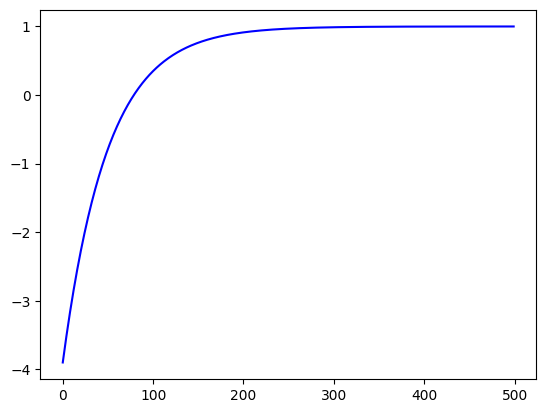

In [28]:
import matplotlib.pyplot as plt

plt.plot(x_list, "b")
plt.show()

- 手写数字识别训练

In [29]:
# 数据由上一个Code Cell完成
import torch
import math

# 1. 定义训练参数（3层卷积，2层全链接）
#   1.1. 1 @28 * 28 ->   6@28 * 28:  6@5*5 的卷积核  -> 6 @ 14 * 14(池化)
#   1.2. 6@14 * 14 ->   16@10 * 10:  16@5*5 的卷积核  -> 10 @ 5 * 5(池化)
#   1.3. 16@5 * 5 ->   120@1 * 1:  120@5*5 的卷积核  （没有池化）
#   1.4. 120 * 84  
#   1.5. 84 * 10   (输出10个特征，分类0-9十个数字)
# 1.1
w_6_5_5 = torch.Tensor(6, 1, 5, 5)   #（C_out, C_in, H_k, W_k）
b_6_5_5 = torch.Tensor(6)               # (C_out)   # 卷积核也可以不使用偏置项的
# 初始化（模仿Torch的源代码，自己采用正态分布，每次计算都是无穷大）
stdv = 1.0 / math.sqrt(1 * 5 * 5)
w_6_5_5.data.uniform_(-stdv, stdv)
b_6_5_5.data.uniform_(-stdv, stdv)
# print(w_6_5_5)

# 1.2 
w_16_5_5 = torch.Tensor(16, 6, 5, 5)
b_16_5_5 = torch.Tensor(16)
# 初始化
stdv = 1.0 / math.sqrt(6 * 5 * 5)
w_16_5_5.data.uniform_(-stdv, stdv)
b_16_5_5.data.uniform_(-stdv, stdv)

# 1.3 
w_120_5_5 = torch.Tensor(120, 16, 5, 5)
b_120_5_5 = torch.Tensor(120) 
# 初始化
stdv = 1.0 / math.sqrt(16 * 5 * 5)
w_120_5_5.data.uniform_(-stdv, stdv)
b_120_5_5.data.uniform_(-stdv, stdv)

# 1.4
w_120_84 = torch.Tensor(84, 120) 
b_120_84 = torch.Tensor(84) 
# 初始化
stdv = 1.0 / math.sqrt(120)   # 使用输入的特征数作为均匀分布的计算基数
w_120_84.data.uniform_(-stdv, stdv)
b_120_84.data.uniform_(-stdv, stdv)

# 1.5
w_84_10 =torch.Tensor(10, 84) 
b_84_10 = torch.Tensor(10)
# 初始化
stdv = 1.0 / math.sqrt(84)
w_84_10.data.uniform_(-stdv, stdv)
b_84_10.data.uniform_(-stdv, stdv)


# print(w_16_5_5)
w_6_5_5.requires_grad = True
b_6_5_5.requires_grad = True
# 1.2 
w_16_5_5.requires_grad = True
b_16_5_5.requires_grad = True
# 1.3 
w_120_5_5.requires_grad = True
b_120_5_5.requires_grad = True
# 1.4
w_120_84.requires_grad = True
b_120_84.requires_grad = True
# 1.5
w_84_10.requires_grad = True
b_84_10.requires_grad = True

# 2. 定义forward模型(为了反复调用，封装成函数)
@torch.enable_grad()
def lenet5_forward(input):
    """
    input的格式：4-D（N, 1, 28, 28）：N表示每批次的样本数量
    out的格式：与input相同4-D（N, 10）：N表示每批次的样本数量
    """
    # 1.1 
    o_c1 = torch.nn.functional.conv2d(input=input, weight=w_6_5_5, bias=b_6_5_5, padding = 2)  # 原始图像28*28
    o_a1 = torch.nn.functional.relu(o_c1)
    o_p1 = torch.nn.functional.max_pool2d(input= o_a1, kernel_size=(2,2))
    o1 = o_p1
    # 1.2
    o_c2 = torch.nn.functional.conv2d(input=o1, weight=w_16_5_5, bias=b_16_5_5)
    o_a2 = torch.nn.functional.relu(o_c2)
    o_p2 = torch.nn.functional.max_pool2d(input= o_a2, kernel_size=(2,2))
    o2 = o_p2
    # 1.3
    o_c3 = torch.nn.functional.conv2d(input=o2, weight=w_120_5_5, bias=b_120_5_5)
    o_a3 = torch.nn.functional.relu(o_c3)
    # 无池化
    # o3 = o_a3.squeeze()    # 格式转换(把最后的1*1直接降维掉），转换为60000 * 120
    o3 = o_a3.view(o_a3.shape[0], o_a3.shape[1])
    # 1.4
    o_c4 = torch.nn.functional.linear(o3, w_120_84, b_120_84)
    o_a4 = torch.nn.functional.relu(o_c4)
    o4 = o_a4
    # 1.5
    o_c5 = torch.nn.functional.linear(o4, w_84_10, b_84_10)
    o_a5 = torch.log_softmax(o_c5, dim=1)
    o5 = o_a5
    return  o5 

# 3. 定义损失模型（封装成函数）
@torch.enable_grad()
def loss_model(out, target):
    loss_ = torch.nn.functional.cross_entropy(out, target)
    return loss_

# 为了速度取1000个样本训练
# train_x = train_x[0:10]
# train_y = train_y[0:10]
# 训练集
x = torch.Tensor(train_x).view(train_x.shape[0], 1, train_x.shape[1], train_x.shape[2])   # N,C,W,H
y = torch.LongTensor(train_y)
# # 测试集
t_x =  torch.Tensor(test_x).view(test_x.shape[0], 1, test_x.shape[1], test_x.shape[2])   # N,C,W,H
t_y =  torch.LongTensor(test_y)

# 训练超参数
# 学习率
learn_rate = 0.001
# 训练轮数
epoch = 500
# 没批样本数
batch_size = 2000
# 批次计算
batch_num = len(train_y) // batch_size

# 轮次循环
for e in range(epoch):
    # 批次循环
    for idx in range(batch_num):
        # 批次样本
        start = idx *batch_size
        end = (idx + 1) * batch_size
        b_x = x[start: end]
        b_y = y[start: end]
        # 计算输出
        b_y_ = lenet5_forward(b_x)
#         break
        # 计算损失
        l_ = loss_model(b_y_, b_y)
        # 计算梯度
        l_.backward(retain_graph=True)
#         print(w_6_5_5.grad)
        # 梯度更新(使用上下文管理器，进制对运算实现图跟踪)
        with torch.autograd.no_grad():
            w_6_5_5 -= learn_rate * w_6_5_5.grad
            b_6_5_5 -= learn_rate * b_6_5_5.grad

            w_16_5_5 -= learn_rate * w_16_5_5.grad
            b_16_5_5 -= learn_rate * b_16_5_5.grad

            w_120_5_5 -= learn_rate * w_120_5_5.grad
            b_120_5_5 -= learn_rate * b_120_5_5.grad

            w_120_84 -= learn_rate * w_120_84.grad
            b_120_84 -= learn_rate * b_120_84.grad
            
            w_84_10 -= learn_rate * w_84_10.grad
            b_84_10 -= learn_rate * b_84_10.grad
            
            # 复原梯度
            w_6_5_5.grad.zero_()
            b_6_5_5.grad.zero_()
            
            w_16_5_5.grad.zero_()
            b_16_5_5.grad.zero_()
            
            w_120_5_5.grad.zero_()
            b_120_5_5.grad.zero_()
            
            w_120_84.grad.zero_()
            b_120_84.grad.zero_()
            
            w_84_10.grad.zero_()
            b_84_10.grad.zero_()
            
    # 每一轮次完毕，输出损失度与测试集准确率
    if e % 100 ==0:
        print(F"第{e:03d}轮")
        print(F"\t损失值：{l_:8.6f}",end="")  
        # 测试集测试
        with torch.autograd.no_grad():   
            predict = lenet5_forward(t_x)
            # 计算准确率
            y_ = predict.argmax(dim=1)
            correct_rate = (y_ == t_y).float().mean()
            print(F"\t测试集准确率：{correct_rate*100: 6.2f}%")
print("------训练完毕------") 

NameError: name 'train_x' is not defined

# 2. torch.nn.functional包

- 封装的是底层函数（不建议直接使用）
    - 卷积（特征）
    - 自注意力（特征：记忆力）
    - ----
    - 线性运算（分类器）
    - ----
    - 激活函数（非线性）
    - 池化函数
    - dropout函数
    - ----
    - 损失函数

# 3. torch.nn

- 把torch.nn.functional的所有运算封装Module
    - 推荐使用：使用模块
    - Module
        - Layer：
            - 基础封装：
                - Conv2d
                - 线性
                - 自注意力
                - -----
                - 损失函数
                - -----
                - 激活
            - 常用层的封装
                - Transformer
                - RNN(GRU, LSTM)
                - BatchNorm
                - 
        - 专用module
            - 使用层数组构建一个Module：Sequential
            - ModuleList
            - ModuleDict

# 4. 其他

- **torch.utils**
    - 数据集与批次数据集
    - 其他工具
- torch.auto_grad
    - 求导封装
- torch.cuda（cuda编程）
    - GPU的底层调用
- **torch.export**（模型导出：量化）
- **torch.onnx**（模型格式）